# Miscellaneous stuff
mostly for plots in the thesis


In [4]:
import numpy as np 
import matplotlib.pyplot as plt 

In [5]:
def phi(I, rmax, beta, T):
    return (rmax)/(1+np.exp(-beta * (I-T)))

In [6]:
def conv_phi(I, rmax, T):
    return rmax * (I>T)

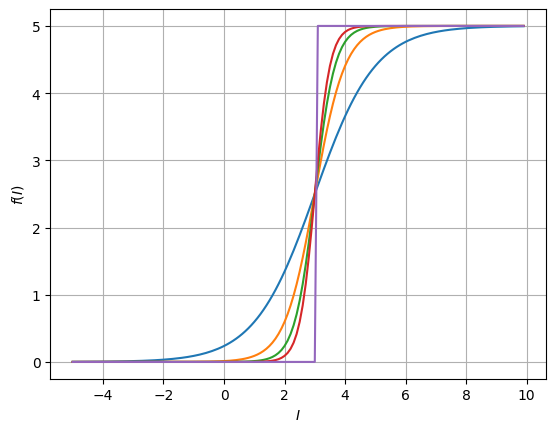

In [41]:
I_space = np.arange(-5, 10, 0.1)
rmax = 5
beta = 1
T = 3

for beta in range(1, 5):
    f_beta = phi(I_space, rmax, beta, T)
    plt.plot(I_space, f_beta)

f_conv = conv_phi(I_space, rmax, T)
plt.plot(I_space, f_conv)
plt.xlabel("$I$")
plt.ylabel("$f(I)$")
plt.grid()
plt.show()

Text(0, 0.5, '$f(I)$')

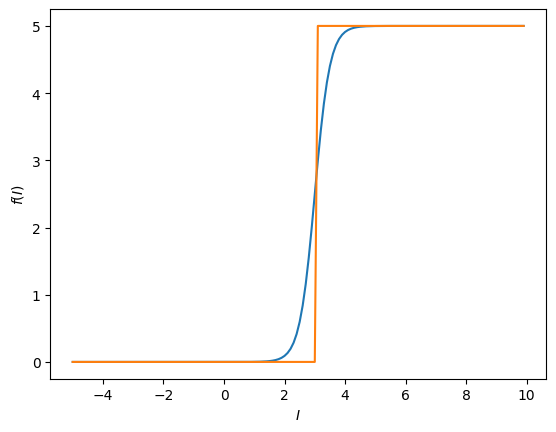

In [35]:
plt.plot(I_space, f_beta)
plt.plot(I_space, f_conv)

plt.xlabel("$I$")
plt.ylabel("$f(I)$")

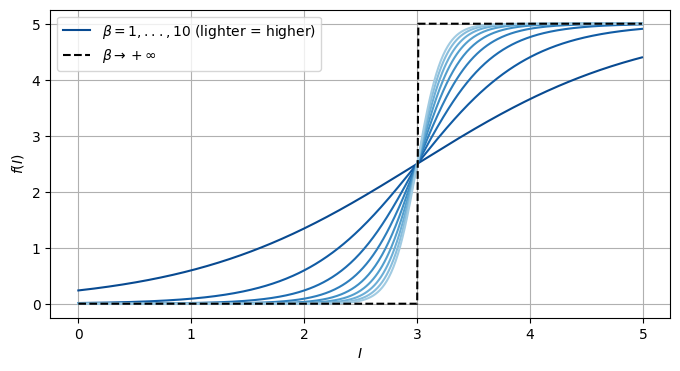

In [75]:
import numpy as np
import matplotlib.pyplot as plt

I_space = np.arange(0, 5, 0.01)
rmax = 5
T = 3

fig, axes = plt.subplots(figsize=(8, 4))

# Generate progressively lighter blues
colors = plt.cm.Blues(np.linspace(0.9, 0.3, 10))

for idx, beta in enumerate(range(1, 10)):
    f_beta = phi(I_space, rmax, beta, T)
    plt.plot(
        I_space,
        f_beta,
        color=colors[idx],
    )

plt.plot([], [], color=colors[0], label=r"$\beta = 1, ..., 10$ (lighter = higher)")

f_conv = conv_phi(I_space, rmax, T)
plt.plot(
    I_space,
    f_conv,
    color="black",
    linestyle="--",
    label=r"$\beta \to +\infty$"
)

plt.xlabel("$I$")
plt.ylabel("$f(I)$")
plt.grid()
plt.legend()
plt.show()

In [1]:
# chua plot 
import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import optax as opx
import matplotlib.pyplot as plt 
import jax.random as jr

jax.config.update("jax_enable_x64", True) # enable 64 float precision for stiff problems

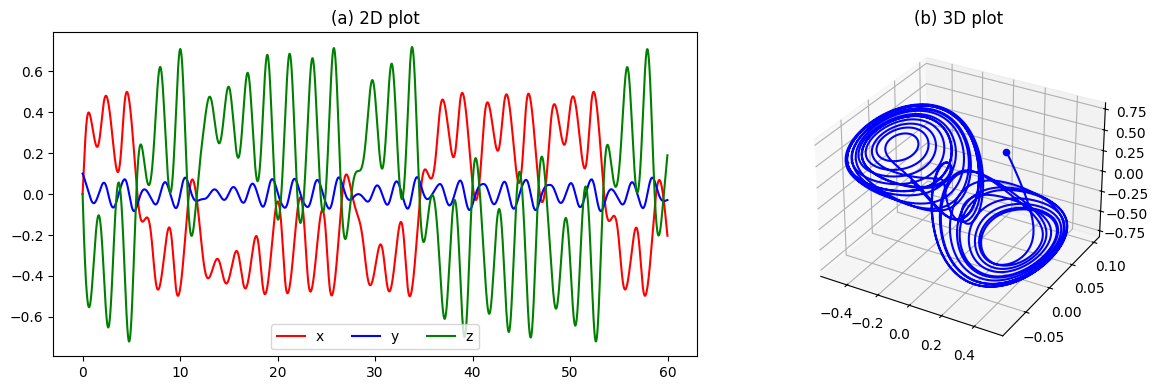

In [35]:
# generate train and val data
ALPHA, BETA, GAMMA, A, C = (10, 16, 0, 1, -0.143)

col_dict = {
    0: 'r', 
    1: 'g',
    2: 'b'
}
var_dict = {
    0: 'x',
    1: 'y',
    2: 'z'
}

def chua_model(t, xyz, args):
    alpha, beta, gamma, a, c = args 
    x,y,z = xyz 
    return jnp.array([
        alpha*(y-a*x**3-c*x),
        x-y+z, 
        -beta*y - gamma*z
    ])

T_MAX = 60

term = dfx.ODETerm(chua_model)
solver = dfx.Dopri5()
y0 = jnp.array((0.0001, 0.1, 0))
y0_alt = jnp.array((0.0001, 0.1, 0.1))
saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 0.01))

sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

fig = plt.figure(figsize=(13, 4))


ax0 = fig.add_subplot(1, 2, 1)
ax0.plot(sol.ts, sol.ys[:, 0], color='red', label='x')
ax0.plot(sol.ts, sol.ys[:, 1], color='blue', label='y')
ax0.plot(sol.ts, sol.ys[:, 2], color='green', label='z')
ax0.legend(ncol=3)
ax0.set_title("(a) 2D plot")

# 3D plot
ax = fig.add_subplot(1, 2, 2, projection='3d')
ax.plot(sol.ys[:, 0],sol.ys[:, 1],sol.ys[:, 2], color='blue', alpha=1)
ax.scatter(sol.ys[0:1, 0],sol.ys[0:1, 1],sol.ys[0:1, 2], color='blue', marker='o')
ax.set_title("(b) 3D plot")

plt.tight_layout()

plt.show()